Loading data from CSV files...
Processing N=1000 per class...
Processing N=1500 per class...
Processing N=2000 per class...
Processing N=2500 per class...
Processing N=3000 per class...
Processing N=3500 per class...
Processing N=4000 per class...
Processing N=4500 per class...
Processing N=5000 per class...
Processing N=5500 per class...
Processing N=6000 per class...


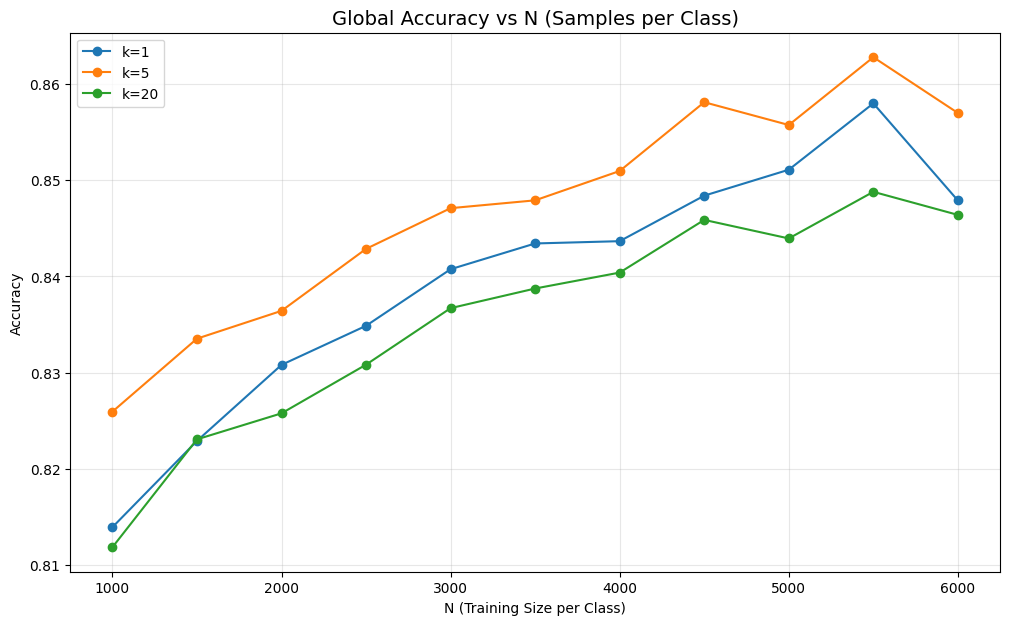

Question 1 Complete. Results saved.


In [1]:
"""
DATA 604 Midterm - Question 1
Implementation of kNN on Fashion MNIST with optimized distance calculations.
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from scipy.stats import mode

# --- 1. DATA LOADING ---
# Loading the files you uploading it
def load_local_data():
    print("Loading data from CSV files...")
    train_df = pd.read_csv('fashion-mnist_train.csv')
    test_df = pd.read_csv('fashion-mnist_test.csv')

    # Combine to create the full 70,000 dataset
    full_df = pd.concat([train_df, test_df], axis=0)

    X = full_df.drop('label', axis=1).values
    y = full_df['label'].values
    return X, y

# --- 2. EXPERIMENT LOGIC ---
def run_q1_experiment(X, y):
    k_list = [1, 2, 5, 10, 15, 20]
    N_list = list(range(1000, 6001, 500))
    np.random.seed(42) # Reproducibility

    results = []

    for N in N_list:
        print(f"Processing N={N} per class...")

        # Step A: Select Training Indices (Balanced)
        train_idx = []
        test_idx = []
        for c in range(10):
            c_indices = np.where(y == c)[0]
            np.random.shuffle(c_indices)
            train_idx.extend(c_indices[:N])
            test_idx.extend(c_indices[N:])

        X_train, y_train = X[train_idx], y[train_idx]
        X_test, y_test = X[test_idx], y[test_idx]

        # Step B: Optimize - Compute 20-NN once per N
        # n_jobs=-1 uses all available CPU cores in Colab
        knn = KNeighborsClassifier(n_neighbors=20, metric='euclidean', n_jobs=-1)
        knn.fit(X_train, y_train)

        # Get distances and indices for the test set
        _, neighbor_indices = knn.kneighbors(X_test)

        # Step C: Evaluate for each k
        for k in k_list:
            # Extract labels of the k closest neighbors
            k_labels = y_train[neighbor_indices[:, :k]]

            # Perform majority voting
            y_pred = mode(k_labels, axis=1, keepdims=True).mode.flatten()

            # Calculate Global & Local Accuracy
            g_acc = accuracy_score(y_test, y_pred)

            res = {'N': N, 'k': k, 'Global_Accuracy': g_acc}
            # Add per-class accuracy
            for c in range(10):
                mask = (y_test == c)
                res[f'Class_{c}_Acc'] = accuracy_score(y_test[mask], y_pred[mask])

            results.append(res)

    return pd.DataFrame(results)

# --- 3. EXECUTION & VISUALIZATION ---
X, y = load_local_data()
df_q1 = run_q1_experiment(X, y)

# Visualization: Global Accuracy
plt.figure(figsize=(12, 7))
for k_val in [1, 5, 20]: # Plotting a subset for clarity
    subset = df_q1[df_q1['k'] == k_val]
    plt.plot(subset['N'], subset['Global_Accuracy'], label=f'k={k_val}', marker='o')

plt.title('Global Accuracy vs N (Samples per Class)', fontsize=14)
plt.xlabel('N (Training Size per Class)')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Save final results for the Appendix
df_q1.to_csv('Question1_Results.csv', index=False)
print("Question 1 Complete. Results saved.")

Running Sequential Indexing for N=1000...
Running Sequential Indexing for N=1500...
Running Sequential Indexing for N=2000...
Running Sequential Indexing for N=2500...
Running Sequential Indexing for N=3000...
Running Sequential Indexing for N=3500...
Running Sequential Indexing for N=4000...
Running Sequential Indexing for N=4500...
Running Sequential Indexing for N=5000...
Running Sequential Indexing for N=5500...
Running Sequential Indexing for N=6000...


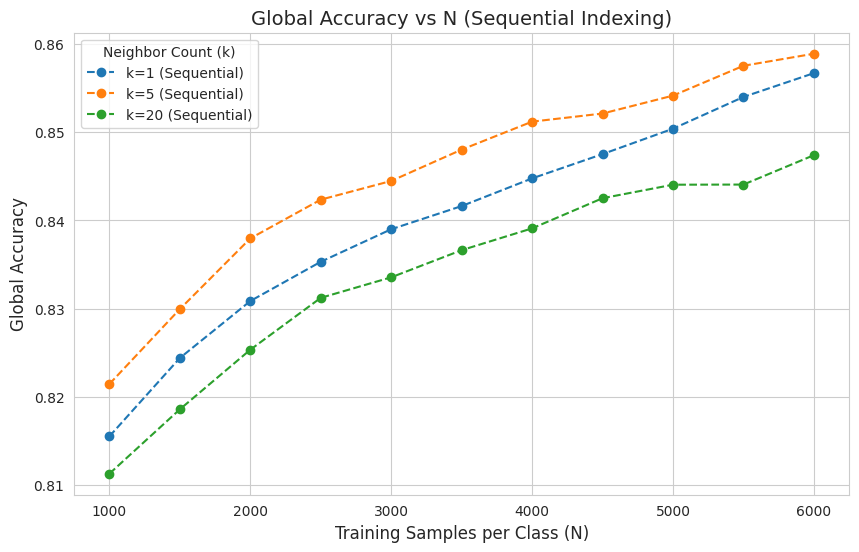

Question 2 completed. Table and Plot generated.


In [2]:
"""
DATA 604 Midterm - Question 2
Sequential Indexing Study with Visualization
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from scipy.stats import mode

# 1. LOAD DATA
# full_df = pd.concat([pd.read_csv('fashion-mnist_train.csv'), pd.read_csv('fashion-mnist_test.csv')], axis=0)
# X = full_df.drop('label', axis=1).values
# y = full_df['label'].values

# 2. EXPERIMENT PARAMETERS
k_list = [1, 2, 5, 10, 15, 20]
N_list = list(range(1000, 6001, 500))
results_q2 = []

# 3. SEQUENTIAL SELECTION LOGIC
for N in N_list:
    print(f"Running Sequential Indexing for N={N}...")
    train_idx, test_idx = [], []
    for c in range(10):
        c_indices = np.where(y == c)[0]
        # Sequential: first N for training, rest for testing
        train_idx.extend(c_indices[:N])
        test_idx.extend(c_indices[N:])

    X_train, y_train = X[train_idx], y[train_idx]
    X_test, y_test = X[test_idx], y[test_idx]

    knn = KNeighborsClassifier(n_neighbors=20, metric='euclidean', n_jobs=-1)
    knn.fit(X_train, y_train)
    _, neighbor_indices = knn.kneighbors(X_test)

    for k in k_list:
        k_labels = y_train[neighbor_indices[:, :k]]
        y_pred = mode(k_labels, axis=1, keepdims=True).mode.flatten()

        g_acc = accuracy_score(y_test, y_pred)
        res = {'N': N, 'k': k, 'Global_Accuracy': g_acc}
        for c in range(10):
            mask = (y_test == c)
            res[f'Class_{c}_Acc'] = accuracy_score(y_test[mask], y_pred[mask])
        results_q2.append(res)

df_q2 = pd.DataFrame(results_q2)

# 4. VISUALIZATION TOOLS
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

# We plot the main k values to see the trend
for k_val in [1, 5, 20]:
    subset = df_q2[df_q2['k'] == k_val]
    plt.plot(subset['N'], subset['Global_Accuracy'], label=f'k={k_val} (Sequential)', marker='o', linestyle='--')

plt.title('Global Accuracy vs N (Sequential Indexing)', fontsize=14)
plt.xlabel('Training Samples per Class (N)', fontsize=12)
plt.ylabel('Global Accuracy', fontsize=12)
plt.legend(title='Neighbor Count (k)')
plt.savefig('Q2_Sequential_Accuracy.png')
plt.show()

# 5. SAVE TABLE
df_q2.to_csv('Question2_Results.csv', index=False)
print("Question 2 completed. Table and Plot generated.")

Running Manhattan Distance (L1) for N=1000...
Running Manhattan Distance (L1) for N=1500...
Running Manhattan Distance (L1) for N=2000...
Running Manhattan Distance (L1) for N=2500...
Running Manhattan Distance (L1) for N=3000...
Running Manhattan Distance (L1) for N=3500...
Running Manhattan Distance (L1) for N=4000...
Running Manhattan Distance (L1) for N=4500...
Running Manhattan Distance (L1) for N=5000...
Running Manhattan Distance (L1) for N=5500...
Running Manhattan Distance (L1) for N=6000...


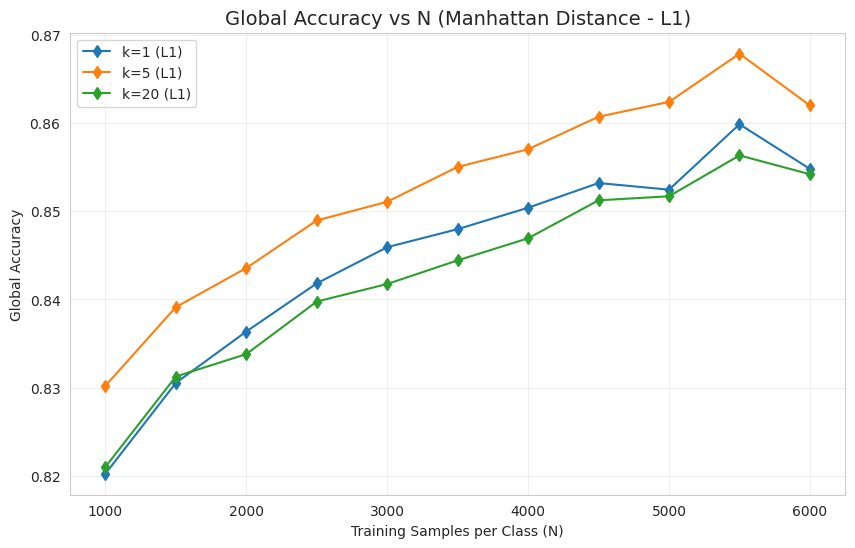

Question 3 Analysis Complete. Results saved to Question3_Results_L1.csv.


In [3]:
"""
DATA 604 Midterm - Question 3
Study of the L1 Norm (Manhattan Distance)
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from scipy.stats import mode

# 1. LOAD DATA
# train_df = pd.read_csv('fashion-mnist_train.csv')
# test_df = pd.read_csv('fashion-mnist_test.csv')
# full_df = pd.concat([train_df, test_df], axis=0)
# X = full_df.drop('label', axis=1).values
# y = full_df['label'].values

# 2. EXPERIMENT PARAMETERS
k_list = [1, 2, 5, 10, 15, 20]
N_list = list(range(1000, 6001, 500))
results_q3 = []
np.random.seed(42) # Best split method: Randomized Stratified

# 3. MANHATTAN DISTANCE LOGIC
for N in N_list:
    print(f"Running Manhattan Distance (L1) for N={N}...")

    # Randomized Stratified Split
    train_idx, test_idx = [], []
    for c in range(10):
        c_indices = np.where(y == c)[0]
        np.random.shuffle(c_indices)
        train_idx.extend(c_indices[:N])
        test_idx.extend(c_indices[N:])

    X_train, y_train = X[train_idx], y[train_idx]
    X_test, y_test = X[test_idx], y[test_idx]

    # KEY CHANGE: metric='manhattan' (L1 Norm)
    knn = KNeighborsClassifier(n_neighbors=20, metric='manhattan', n_jobs=-1)
    knn.fit(X_train, y_train)
    _, neighbor_indices = knn.kneighbors(X_test)

    for k in k_list:
        k_labels = y_train[neighbor_indices[:, :k]]
        y_pred = mode(k_labels, axis=1, keepdims=True).mode.flatten()

        g_acc = accuracy_score(y_test, y_pred)
        res = {'N': N, 'k': k, 'Global_Accuracy': g_acc, 'Metric': 'L1'}

        # Local Accuracy
        for c in range(10):
            mask = (y_test == c)
            res[f'Class_{c}_Acc'] = accuracy_score(y_test[mask], y_pred[mask])

        results_q3.append(res)

# 4. SAVE AND PLOT
df_q3 = pd.DataFrame(results_q3)
df_q3.to_csv('Question3_Results_L1.csv', index=False)

# Visualization: Comparing L1 Trends
plt.figure(figsize=(10, 6))
for k_val in [1, 5, 20]:
    subset = df_q3[df_q3['k'] == k_val]
    plt.plot(subset['N'], subset['Global_Accuracy'], label=f'k={k_val} (L1)', marker='d')

plt.title('Global Accuracy vs N (Manhattan Distance - L1)', fontsize=14)
plt.xlabel('Training Samples per Class (N)')
plt.ylabel('Global Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('Q3_Manhattan_Accuracy.png')
plt.show()

print("Question 3 Analysis Complete. Results saved to Question3_Results_L1.csv.")